In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from openmm.app import *
from openmm import *
from openmm.unit import *
from pdbfixer import PDBFixer
from io import StringIO
from tqdm import tqdm
import numpy as np
import os
import mdtraj as md
import matplotlib.pyplot as plt
import io
import matplotlib.pyplot as plt
from openmm.app import PDBFile, ForceField, Modeller, Simulation, NoCutoff, HBonds
from openmm import VerletIntegrator, LocalEnergyMinimizer
from openmm.unit import *
import torch
from rmsd import kabsch_rmsd
from logging_utils import save_ovito_traj

In [33]:
def fix_xtc_file(xtc_path, pdb_top_path, freq=5):
    """
    Fixes selected frames from an XTC trajectory by adding missing atoms/hydrogens,
    and returns original atom positions and indices for force slicing.

    Returns:
    - fixed_pdb_path: Path to fixed multi-frame PDB
    - original_positions: np.array [N_frames, N_atoms, 3] in Ångströms
    - atom_indices: list of atom indices that existed in the original pdb topology
    """
    traj = md.load(xtc_path, top=pdb_top_path)
    fixed_pdb_path = os.path.splitext(xtc_path)[0] + "_fixed.pdb"

    has_written_header = False
    selected_positions = []
    selected_indices = []

    # atom indices that match the original .pdb (before hydrogens are added)
    original_atom_indices = list(range(traj.n_atoms))

    print("Fixing missing atoms and hydrogens...")
    with open(fixed_pdb_path, "w") as output_pdb:
        count = 0
        for i in tqdm(range(len(traj))):
            if i % freq == 0 or i == len(traj) - 1:
                count += 1
                selected_indices.append(i)
                selected_positions.append(traj.xyz[i] * 10.0)  # nm → Å

                temp_pdb_path = f"temp_frame_{i}.pdb"
                traj[i].save_pdb(temp_pdb_path)

                fixer = PDBFixer(filename=temp_pdb_path)
                fixer.findMissingResidues()
                fixer.findMissingAtoms()
                fixer.addMissingAtoms()
                fixer.addMissingHydrogens(pH=7.0)

                if not has_written_header:
                    PDBFile.writeHeader(fixer.topology, output_pdb)
                    has_written_header = True
                PDBFile.writeModel(fixer.topology, fixer.positions, output_pdb, count)

                os.remove(temp_pdb_path)

        PDBFile.writeFooter(fixer.topology, output_pdb)

    return fixed_pdb_path, np.array(selected_positions), original_atom_indices



def compute_forces_and_positions(xtc_path, pdb_top_path, compute_freq=5):
    """
    Compute forces on fixed structures, but return only the components
    corresponding to the original atoms before fixing.

    Returns:
    - forces: np.array [N_frames, N_original_atoms, 3] (in kJ/mol/nm)
    - positions: np.array [N_frames, N_original_atoms, 3] (in Ångströms)
    """
    fixed_pdb_path, original_positions, original_atom_indices = fix_xtc_file(
        xtc_path, pdb_top_path, freq=compute_freq
    )

    with open(fixed_pdb_path, "r") as f:
        pdb_text = f.read()

    frames = pdb_text.split("ENDMDL")
    frames = [frame.strip() + "\nENDMDL\n" for frame in frames if "MODEL" in frame]

    forcefield = ForceField("amber14-all.xml")
    selected_forces = []

    print("Computing forces...")
    for i, frame in tqdm(enumerate(frames)):
        pdb = PDBFile(io.StringIO(frame))
        modeller = Modeller(pdb.topology, pdb.positions)

        system = forcefield.createSystem(
            modeller.topology, nonbondedMethod=NoCutoff, constraints=HBonds
        )

        integrator = VerletIntegrator(1.0 * femtoseconds)
        simulation = Simulation(modeller.topology, system, integrator)
        simulation.context.setPositions(modeller.positions)

        state = simulation.context.getState(getForces=True)
        forces = state.getForces(asNumpy=True).value_in_unit(kilojoule_per_mole / nanometer)

        # Only keep forces corresponding to atoms from the original topology
        trimmed_forces = forces[original_atom_indices]
        selected_forces.append(trimmed_forces)

    return np.array(selected_forces), original_positions


In [34]:
xtc_path = "/data/sanjeevr/4AA_sim/AKIR/AKIR.xtc"
pdb_top_path = "/data/sanjeevr/4AA_sim/AKIR/AKIR.pdb"
forces, positions = compute_forces_and_positions(xtc_path, pdb_top_path, compute_freq=10000)

Fixing missing atoms and hydrogens...


100%|██████████| 999999/999999 [00:30<00:00, 33332.28it/s]


Computing forces...


101it [00:23,  4.27it/s]


In [35]:
forces.shape, positions.shape

((101, 34, 3), (101, 34, 3))

In [36]:
import os
import shutil
import wandb
import json
import argparse
import pickle
from os.path import join
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from models import get_model, CommittorNN
from models.ddpm import GaussianDiffusion
from models.flow_matching import FlowMatching
from ema_pytorch import EMA
import mdtraj
from datasets.dataset_utils_empty import (
    get_dataset,
    Molecules,
    AtomSelection,
    DEShawDataset,
    to_angstrom,
    norm_stds,
)
# from evaluate.evaluate_fastfolders import (
#     evaluate_fastfolders,
#     CLUSTER_ENDPOINTS,
#     CLUSTER_ENDPOINTS_ALL_ATOM,
# )


# from evaluate.evaluate_tetrapeptides import evaluate_tetrapeptide
from evaluate.evaluators import (
    sample_from_model,
    sample_interpolations_from_model,
    TicEvaluator,
)
from evaluate.evaluators_CGflowmatching import get_torsions
from evaluate.msm_utils import discretize_trajectory
from dynamics.langevin import LangevinDiffusion
from utils import (
    SamplerWrapper,
    InterpolatorWrapper,
    OMInterpolatorWrapper,
    filter_by_rmsd,
    slerp,
    validate_git_status,
    cycle,
)
from logging_utils import save_ovito_traj
from actions import TruncatedAction, S2Action, HutchinsonAction

from dynamics.langevin import temp_dict
import mdtraj as md
from torch.utils.tensorboard import SummaryWriter
import time
import matplotlib.pyplot as plt
import contextlib
device = torch.device("cuda:9" if torch.cuda.is_available() else "cpu")

In [8]:


args_path = "saved_models/tetrapeptides_all_atom/args.pickle"
model_path = "saved_models/tetrapeptides_all_atom/model-best.pt"
with open(args_path, "rb") as f:
    args = pickle.load(f)

# make dummy trainset object
class Args:
    def __init__(self):
        self.num_beads = 56
        self.bead_onehot = torch.eye(56)

trainset = Args()
norm_factor = 1.0

# Load model

model_nn = get_model(args, trainset, device)
model_cls = GaussianDiffusion

DDPM_model = model_cls(
    model=model_nn,
    features=trainset.bead_onehot,
    num_atoms=trainset.num_beads,
    timesteps=args.diffusion_steps,
    norm_factor=norm_factor,
    loss_weights=args.loss_weights,
    temp_data=350,
).to(device)
model = EMA(DDPM_model)

data_dict = torch.load(model_path, weights_only=True)
model.load_state_dict(data_dict["ema"])
model.model.device = device

In [46]:
from mdgen.mdgen.residue_constants import restype_order
import mdgen.mdgen.residue_constants as rc
from ase.data import atomic_numbers
from itertools import chain
seqres = "AVGR"
atom_names = [
                rc.restype_name_to_atom14_names[rc.aa_one_to_three_letter[c]]
                for c in seqres
            ]
# find num atoms per residue that are not ''
num_atoms_per_residue = [
    len([a for a in atom if a != ""]) for atom in atom_names
]
atom_names = list(chain.from_iterable(atom_names))

# remove '' elements from list
atom_names = [x[0] if x else "" for x in atom_names]
z = torch.tensor(
    [atomic_numbers[a] if a else 0 for a in atom_names]
).long()


# Update positions to have zeros for missing atoms
new_pos = torch.zeros((positions.shape[0], 56, 3), device=device)
new_forces = torch.zeros((positions.shape[0], 56, 3), device=device)
count = 0
for i in range(len(z)):
    if z[i] != 0:
        new_pos[:, i, :] = torch.tensor(positions[:, count, :], device=device)
        new_forces[:, i, :] = torch.tensor(forces[:, count, :], device=device)
        count +=1
positions = new_pos
forces = new_forces

/tmp/ipykernel_936686/3907619622.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  new_pos[:, i, :] = torch.tensor(positions[:, count, :], device=device)
/tmp/ipykernel_936686/3907619622.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  new_forces[:, i, :] = torch.tensor(forces[:, count, :], device=device)


In [45]:
forces.shape

torch.Size([101, 27, 3])

/tmp/ipykernel_936686/514333536.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  forces = torch.tensor(forces)


latent time: 0.0


1it [00:00, 13.01it/s]


latent time: 1.1111111111111112


1it [00:00, 13.17it/s]


...

1it [00:00, 13.27it/s]


latent time: 8.88888888888889


1it [00:00, 13.25it/s]


latent time: 10.0


1it [00:00, 13.21it/s]


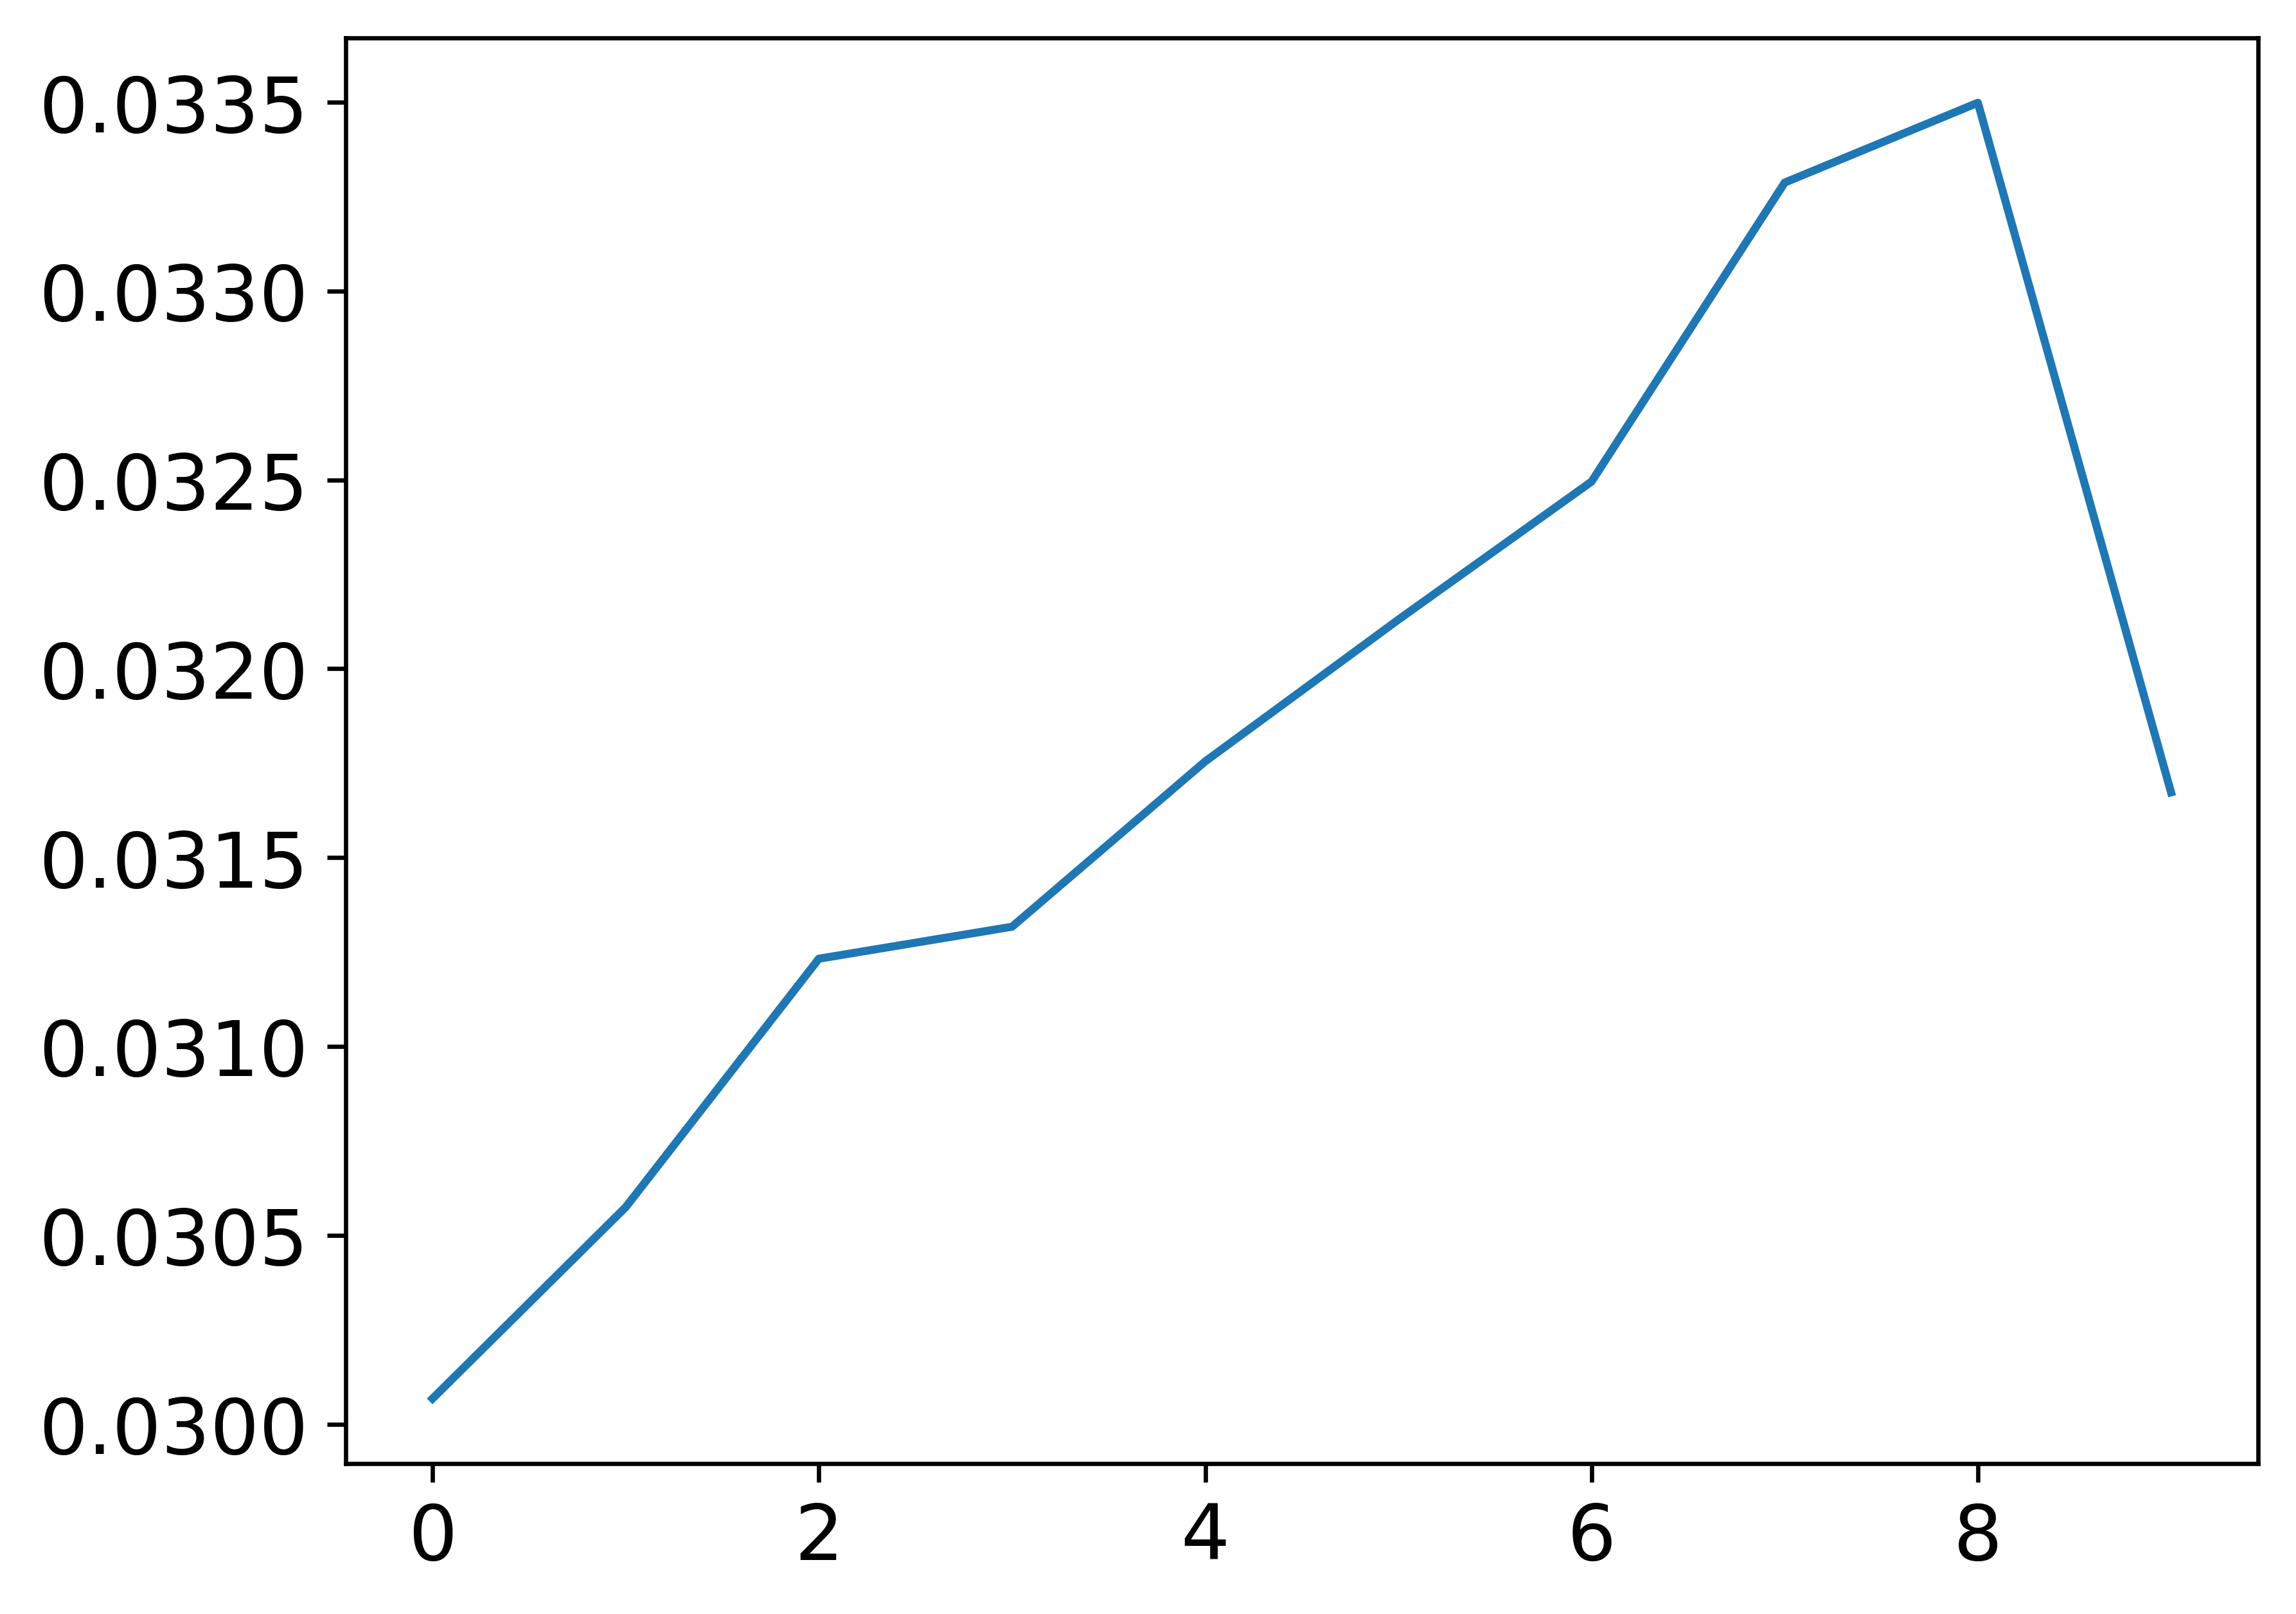

In [48]:
subset_of_gt_traj = positions
forces = torch.tensor(forces)
from tqdm import tqdm
all_cosine_sims = []
for latent_time in np.linspace(0.0, 10.0, 10):
    print(f"latent time: {latent_time}")
    cosine_sims = []
    for batch in tqdm(zip(subset_of_gt_traj.split(256), forces.split(256))):
        pos, force = batch
        pos = pos.to(device)
        force = force.to(device)
        with torch.no_grad():
            model_force = model.model.force_func(pos / norm_factor, latent_time, z=z.unsqueeze(0).repeat(pos.shape[0], 1))
            model_force = model_force[:, z!=0]
            force = force[:, z!=0]
            cosine_sims.append(torch.nn.functional.cosine_similarity(force, model_force, dim=-1).mean().unsqueeze(0).detach())
    cosine_sims = torch.cat(cosine_sims)
    all_cosine_sims.append(cosine_sims.mean().cpu())
    
import matplotlib.pyplot as plt
plt.plot(np.arange(10), all_cosine_sims)


        